### Imports

In [1]:
import pandas as pd
import numpy as np

from xgboost import XGBClassifier

from sklearn.model_selection import GroupKFold
from sklearn.metrics import accuracy_score, log_loss

import matplotlib.pyplot as plt
import seaborn as sns

import joblib

### Load ML Dataset

In [2]:
df = pd.read_csv("../data/processed/f1_ml_dataset.csv") 
df.head()

,grid_position,quali_position,driver_avg_finish_last3,driver_avg_points_last3,constructor_avg_points_last3,driver_win_rate_at_circuit,driver_dnf_rate,driver_points_so_far,constructor_points_so_far,driver_encoded,constructor_encoded,circuit_encoded,winner,race_id
0,17,18.0,20.00,0.00,0.00,0.0,0.0,0.0,0.0,0,15,2,0,1046
1,13,13.0,20.00,0.00,0.33,0.0,0.0,0.0,0.0,1,14,0,0,1010
2,12,12.0,14.00,0.00,0.33,0.0,0.0,0.0,1.0,1,14,2,0,1011
3,11,12.0,11.50,1.00,1.00,0.0,0.0,2.0,3.0,1,14,3,0,1013
4,11,12.0,11.33,0.67,0.67,0.0,0.0,2.0,3.0,1,14,4,0,1014


### Define Features & Target

In [3]:
TARGET = "winner"

FEATURES = [
    "grid_position",
    "quali_position",
    "driver_avg_finish_last3",
    "driver_avg_points_last3",
    "constructor_avg_points_last3",
    "driver_win_rate_at_circuit",
    "driver_dnf_rate",
    "driver_points_so_far",
    "constructor_points_so_far",
    "driver_encoded",
    "constructor_encoded",
    "circuit_encoded"
]

X = df[FEATURES]
y = df[TARGET]
groups = df['race_id']

### Model

In [4]:
model = XGBClassifier(
    n_estimators = 300,
    max_depth    = 5,
    learning_rate= 0.01,
    subsample    = 0.8,
    colsample_bytree = 0.8,
    objective="binary:logistic",
    n_jobs       = -1,
    eval_metric  = "logloss",
    random_state = 42
)
model

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_metho

### GroupKFold Cross Validation
This prevents:
- same race appearing in train & validation
- data leakage

In [5]:
gkf = GroupKFold(n_splits=5)
gkf

GroupKFold(n_splits=5, random_state=None, shuffle=False)

### Traning Loops

In [6]:
log_losses = [] 
accuracies = [] 
top3_accuracies = [] 
fold = 1

for train_idx, val_idx in gkf.split(X,y,groups):
    print(f"\n========== Fold {fold} ==========")
    X_train = X.iloc[train_idx]
    X_val   = X.iloc[val_idx]

    y_train = y.iloc[train_idx]
    y_val   = y.iloc[val_idx]

    val_races = groups.iloc[val_idx]

    # Train Model
    model.fit(X_train, y_train)
    # Predict Probabilities
    preds_proba = model.predict_proba(X_val)[:, 1]
    # Binary predictions 
    preds = (preds_proba > 0.5).astype(int)

    # Metrics:
    fold_logloss = log_loss(y_val, preds)
    fold_acc = accuracy_score(y_val, preds)
    log_losses.append(fold_logloss)
    accuracies.append(fold_acc)
    # ----------------------------- 
    # Top-3 Accuracy 
    # -----------------------------
    val_results = pd.DataFrame({
        "race_id" : val_races.values,
        "actual"  : y_val.values,
        "prob"    : preds_proba
    })
    top3_correct = 0
    total_races  = 0

    for race_id in val_results["race_id"].unique():
        race_df = val_results[val_results["race_id"] == race_id]
        top3 = race_df.sort_values(by="prob", ascending=False).head(3)
        if top3["actual"].sum() > 0:
            top3_correct += 1
        total_races += 1
    top3_acc = top3_correct / total_races 
    top3_accuracies.append(top3_acc)
    
    # -----------------------------
    # Print Fold Metrics 
    # ----------------------------- 
    print(f"Log Loss: {fold_logloss:.4f}") 
    print(f"Accuracy: {fold_acc:.4f}") 
    print(f"Top-3 Accuracy: {top3_acc:.4f}") 
    fold += 1
    


========== Fold 1 ==========
Log Loss: 1.5018
Accuracy: 0.9583
Top-3 Accuracy: 0.8333

========== Fold 2 ==========
Log Loss: 1.7450
Accuracy: 0.9516
Top-3 Accuracy: 0.8333

========== Fold 3 ==========
Log Loss: 1.4442
Accuracy: 0.9599
Top-3 Accuracy: 0.9333

========== Fold 4 ==========
Log Loss: 1.4466
Accuracy: 0.9599
Top-3 Accuracy: 0.8333

========== Fold 5 ==========
Log Loss: 1.4915
Accuracy: 0.9586
Top-3 Accuracy: 0.8621


### Final Cross Validation Results

In [7]:
print(f"Average Log Loss: {np.mean(log_losses):.4f}") 
print(f"Average Accuracy: {np.mean(accuracies):.4f}") 
print(f"Average Top-3 Accuracy: {np.mean(top3_accuracies):.4f}")

Average Log Loss: 1.5258
Average Accuracy: 0.9577
Average Top-3 Accuracy: 0.8591


In [8]:
model.fit(X,y)
print("Final model trained on full dataset.")

Final model trained on full dataset.


### Feature Importance

In [9]:
importance_df = pd.DataFrame({'Features' : FEATURES, 'Importance':model.feature_importances_})
importance_df = importance_df.sort_values(by='Importance',ascending=False)
importance_df

,Features,Importance
1,quali_position,0.424371
0,grid_position,0.158716
3,driver_avg_points_last3,0.105008
10,constructor_encoded,0.049655
9,driver_encoded,0.044310
4,constructor_avg_points_last3,0.041902
2,driver_avg_finish_last3,0.038880
7,driver_points_so_far,0.029438
6,driver_dnf_rate,0.027509
8,constructor_points_so_far,0.027486


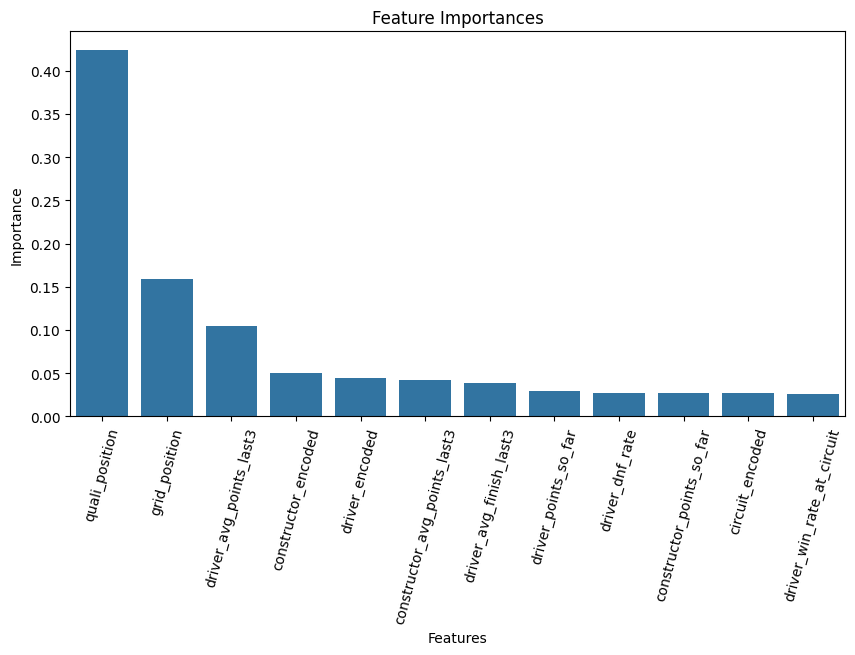

In [10]:
plt.figure(figsize=(10,5))
sns.barplot(x = importance_df['Features'], y = importance_df['Importance'])
plt.title("Feature Importances")
plt.xticks(rotation=75)
plt.show()

### Save Trained Model

In [11]:
joblib.dump(model, "../models/f1_xgboost_model.pkl")
joblib.dump(FEATURES, "../models/model_features.pkl")
print("Model saved successfully.")

Model saved successfully.
